# NUTS retrieval with Diffgrid and PreMODIT

This tutorial compares a pressure-layer aligned `OpaDiffgrid` retrieval with its direct `OpaPremodit` teacher. Both runs use the same atmospheric model, mock observation, priors, random keys, and NUTS settings. Only the opacity evaluation changes.

Diffgrid is independent of the PreMODIT `diffmode`. It stores $\log \sigma$ and $\partial \log \sigma/\partial(1/T)$ at fixed atmospheric pressures. The slopes are generated with `jax.jvp`; retrieval differentiates the ordinary JAX cubic Hermite interpolation rather than using a custom derivative rule.

The example uses a small, self-contained CO-like line snapshot so that it runs without downloading a molecular database. It is intended to demonstrate the retrieval and benchmarking workflow rather than provide a scientific CO line list.

The comparison separates:

1. the common PreMODIT teacher setup,
2. the one-time Diffgrid table build,
3. compile plus first forward evaluation,
4. steady forward latency, and
5. NUTS warmup and posterior sampling.

All timings synchronize JAX explicitly. Absolute values depend on the backend and hardware.

In [1]:
from time import perf_counter

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
from IPython.display import display
from jax import config
from numpyro.diagnostics import summary as diagnostic_summary
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_value

from exojax.database.contracts import Lines, MDBMeta, MDBSnapshot
from exojax.opacity import OpaDiffgrid, OpaPremodit
from exojax.rt import ArtEmisPure
from exojax.utils.grids import wavenumber_grid

config.update("jax_enable_x64", True)

jax.devices()

[CpuDevice(id=0)]

## A self-contained teacher

`OpaDiffgrid` can use any differentiable opacity calculator with an `xsmatrix` method. PreMODIT is the standard teacher. Here we construct a small data-only `MDBSnapshot`; in a production analysis, replace this cell with the usual `MdbExomol` or `MdbHitemp` setup.

In [2]:
def make_demo_snapshot():
    rng = np.random.default_rng(7)
    number_of_lines = 36
    nu_lines = np.linspace(2295.0, 2305.0, number_of_lines)
    nu_lines += rng.uniform(-0.08, 0.08, number_of_lines)

    meta = MDBMeta(
        dbtype="exomol",
        molmass=28.0,
        T_gQT=np.array([300.0, 500.0, 800.0, 1200.0, 1800.0, 2400.0]),
        gQT=np.array([1.0, 1.45, 2.25, 3.55, 5.7, 8.4]),
    )
    lines = Lines(
        nu_lines=nu_lines,
        elower=np.linspace(50.0, 3500.0, number_of_lines),
        line_strength_ref_original=10.0
        ** rng.uniform(-24.0, -21.8, number_of_lines),
    )
    return MDBSnapshot(
        meta=meta,
        lines=lines,
        n_Texp=rng.uniform(0.35, 0.75, number_of_lines),
        alpha_ref=rng.uniform(0.04, 0.08, number_of_lines),
    )


snapshot = make_demo_snapshot()

## Spectral grid, atmosphere, and temperature envelope

Diffgrid is tied to the exact pressure layers used to construct it. Its temperature nodes must also cover every layer temperature reachable under the prior. We therefore evaluate the four corners of the $T_0$ and $\alpha$ prior before building the table.

The nodes are evenly spaced in inverse temperature, not temperature.

In [3]:
nu_grid, _, _ = wavenumber_grid(
    2290.0,
    2310.0,
    256,
    unit="cm-1",
    xsmode="diffgrid",
)
art = ArtEmisPure(
    nu_grid=nu_grid,
    pressure_top=0.1,
    pressure_btm=10.0,
    nlayer=16,
    rtsolver="fbased2st",
    nstream=2,
)

temperature_min = 500.0
temperature_max = 1800.0
art.change_temperature_range(temperature_min, temperature_max)

T0_bounds = (900.0, 1200.0)
alpha_bounds = (0.04, 0.12)
log10_mmr_bounds = (-3.5, -2.5)
pressure_host = np.asarray(art.pressure)
prior_profiles = np.stack(
    [
        T0 * pressure_host**alpha
        for T0 in T0_bounds
        for alpha in alpha_bounds
    ]
)
prior_temperature_range = (
    float(prior_profiles.min()),
    float(prior_profiles.max()),
)
assert temperature_min <= prior_temperature_range[0]
assert prior_temperature_range[1] <= temperature_max
prior_temperature_range

xsmode =  diffgrid
xsmode assumes ESLOG in wavenumber space: xsmode=diffgrid
Your wavelength grid is in ***  descending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
rtsolver:  fbased2st
Flux-based two-stream solver, isothermal layer (ExoJAX1, HELIOS-R1 like)


/home/kawahara/exojax/src/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=29324.815216457522
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)


(682.7198175262654, 1581.9080862676883)

## Build PreMODIT and Diffgrid

The PreMODIT setup is common to both workflows because it is the Diffgrid teacher. The Diffgrid table is an additional one-time cost. It stores two arrays with shape `(nlayer, ntemperature, nnu)`: the log cross section and its inverse-temperature derivative.

In [4]:
teacher_start = perf_counter()
opa_premodit = OpaPremodit.from_snapshot(
    snapshot,
    nu_grid,
    auto_trange=(temperature_min, temperature_max),
    broadening_resolution={"mode": "single", "value": None},
    allow_32bit=True,
)
jax.block_until_ready(opa_premodit.lbd_coeff)
teacher_build_seconds = perf_counter() - teacher_start

inverse_temperature_nodes = np.linspace(
    1.0 / temperature_max,
    1.0 / temperature_min,
    17,
)
temperature_nodes = 1.0 / inverse_temperature_nodes

diffgrid_start = perf_counter()
opa_diffgrid = OpaDiffgrid(
    opa_premodit,
    temperature_grid=temperature_nodes,
    pressure_grid=pressure_host,
)
jax.block_until_ready(opa_diffgrid.log_cross_section_grid)
jax.block_until_ready(opa_diffgrid.log_cross_section_derivative_grid)
diffgrid_build_seconds = perf_counter() - diffgrid_start

# Validate pressure once, outside JIT and NUTS.
opa_diffgrid.check_pressure_grid(pressure_host)

diffgrid_bytes = (
    np.asarray(opa_diffgrid.log_cross_section_grid).nbytes
    + np.asarray(opa_diffgrid.log_cross_section_derivative_grid).nbytes
)
pd.DataFrame(
    {
        "seconds": [teacher_build_seconds, diffgrid_build_seconds],
        "diffgrid_payload_MiB": [np.nan, diffgrid_bytes / 2.0**20],
    },
    index=["PreMODIT teacher", "Diffgrid incremental table"],
)

default elower grid trange (degt) file version: 2
Robust range: 485.7803992045456 - 1868.9917520900296 K


max value of  ngamma_ref_grid : 1.008670234277206
min value of  ngamma_ref_grid : 0.5133890732238879
ngamma_ref_grid grid : [0.77544616]
max value of  n_Texp_grid : 0.7368592941589471
min value of  n_Texp_grid : 0.36007874832070413
n_Texp_grid grid : [0.56999234]
Single broadening parameter: ngamma_ref= 0.7754461550838762 n_Texp= 0.5699923373761998
Premodit: Twt= 1308.7979974283842 K Tref= 570.4914318566549 K


,seconds,diffgrid_payload_MiB
PreMODIT teacher,0.302982,NaN
Diffgrid incremental table,0.693336,1.0625


## One model factory, two opacity methods

Inside a compiled Diffgrid model, call `xsmatrix(temperature)` without a pressure argument. Pressure has already been bound to the table, and a traced pressure argument is intentionally rejected. PreMODIT continues to receive both temperature and pressure.

Apart from that branch, the two forward models are identical.

In [5]:
gravity = 1.0e5


def make_raw_forward(opa):
    def raw_forward(T0, alpha, log10_mmr):
        temperature = art.powerlaw_temperature(T0, alpha)
        if opa.method == "diffgrid":
            cross_section = opa.xsmatrix(temperature)
        else:
            cross_section = opa.xsmatrix(temperature, art.pressure)
        mmr_profile = art.constant_mmr_profile(10.0**log10_mmr)
        dtau = art.opacity_profile_xs(
            cross_section,
            mmr_profile,
            snapshot.meta.molmass,
            gravity,
        )
        return art.run(dtau, temperature)

    return raw_forward


raw_forward_premodit = make_raw_forward(opa_premodit)
raw_forward_diffgrid = make_raw_forward(opa_diffgrid)
truth = {"T0": 1050.0, "alpha": 0.08, "log10_mmr": -3.0}
truth_arguments = tuple(truth.values())

truth_raw_flux = jax.jit(raw_forward_premodit)(*truth_arguments)
jax.block_until_ready(truth_raw_flux)
flux_scale = float(jnp.max(truth_raw_flux))


def normalize_forward(raw_forward):
    def forward(T0, alpha, log10_mmr):
        return raw_forward(T0, alpha, log10_mmr) / flux_scale

    return forward


forward_models = {
    "premodit": normalize_forward(raw_forward_premodit),
    "diffgrid": normalize_forward(raw_forward_diffgrid),
}

## Mock observation and interpolation check

The mock observation is generated by direct PreMODIT at temperatures that are not generally table nodes. Before retrieval, compare the two forward models at the truth, all eight prior corners, and fixed random draws from the three-dimensional prior. Expressing the difference in units of observational noise makes the node-density decision relevant to the inference.

This finite probe is a diagnostic rather than a proof over the continuous prior. If it fails for a real model, increase the number of inverse-temperature nodes or revise the temperature range.

,rms_error/noise,max_abs_error/noise
truth,0.005260,0.011316
prior probe maximum,0.009756,0.031918


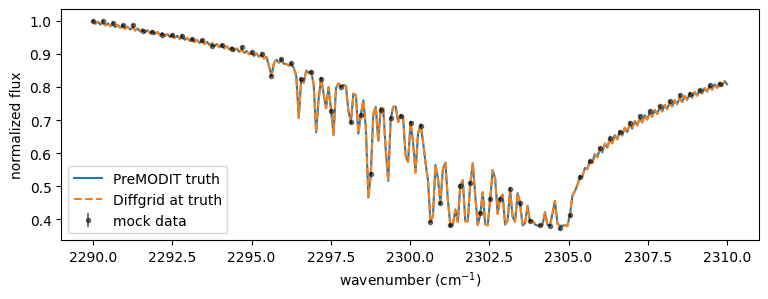

In [6]:
noise_sigma = 0.004
observation_index = jnp.arange(0, len(nu_grid), 4)
truth_flux = np.asarray(forward_models["premodit"](*truth_arguments))
observed_flux = truth_flux[::4] + np.random.default_rng(12).normal(
    0.0,
    noise_sigma,
    len(observation_index),
)

prior_probe_rng = np.random.default_rng(21)
prior_corners = np.asarray(
    [
        (T0, alpha, log10_mmr)
        for T0 in T0_bounds
        for alpha in alpha_bounds
        for log10_mmr in log10_mmr_bounds
    ]
)
prior_draws = np.column_stack(
    (
        prior_probe_rng.uniform(*T0_bounds, size=128),
        prior_probe_rng.uniform(*alpha_bounds, size=128),
        prior_probe_rng.uniform(*log10_mmr_bounds, size=128),
    )
)
probe_points = np.vstack((truth_arguments, prior_corners, prior_draws))
probe_errors = []
for parameters in probe_points:
    expected = np.asarray(forward_models["premodit"](*parameters))[::4]
    actual = np.asarray(forward_models["diffgrid"](*parameters))[::4]
    probe_errors.append((actual - expected) / noise_sigma)
probe_errors = np.asarray(probe_errors)
probe_rms = np.sqrt(np.mean(probe_errors**2, axis=1))
probe_max_abs = np.max(np.abs(probe_errors), axis=1)

accuracy_table = pd.DataFrame(
    {
        "rms_error/noise": [probe_rms[0], probe_rms[1:].max()],
        "max_abs_error/noise": [
            probe_max_abs[0],
            probe_max_abs[1:].max(),
        ],
    },
    index=["truth", "prior probe maximum"],
)
display(accuracy_table)
assert accuracy_table["max_abs_error/noise"].max() < 0.1

plt.figure(figsize=(9, 3))
plt.plot(nu_grid, truth_flux, label="PreMODIT truth")
plt.plot(
    nu_grid,
    np.asarray(forward_models["diffgrid"](*truth_arguments)),
    "--",
    label="Diffgrid at truth",
)
plt.errorbar(
    np.asarray(nu_grid)[::4],
    observed_flux,
    yerr=noise_sigma,
    fmt=".",
    color="black",
    alpha=0.5,
    label="mock data",
)
plt.xlabel("wavenumber (cm$^{-1}$)")
plt.ylabel("normalized flux")
plt.legend()
plt.show()

## Forward-model speed

JAX dispatch is asynchronous, so the benchmark blocks after compilation and after every repeated evaluation. The first-call column includes compilation. The warm latency is a better measure of the opacity path itself; compilation can depend on execution order and cache state.

In [7]:
def benchmark_forward(forward, number_of_repeats=50):
    compiled = jax.jit(forward)

    start = perf_counter()
    value = compiled(*truth_arguments)
    jax.block_until_ready(value)
    first_call_seconds = perf_counter() - start

    start = perf_counter()
    for _ in range(number_of_repeats):
        value = compiled(*truth_arguments)
        jax.block_until_ready(value)
    warm_seconds = (perf_counter() - start) / number_of_repeats
    return compiled, first_call_seconds, warm_seconds


compiled_forward = {}
forward_timing_records = []
for method, forward in forward_models.items():
    compiled, first_call, warm = benchmark_forward(forward)
    compiled_forward[method] = compiled
    forward_timing_records.append(
        {
            "method": method,
            "compile_and_first_s": first_call,
            "warm_latency_ms": 1.0e3 * warm,
        }
    )

forward_timing = pd.DataFrame(forward_timing_records).set_index("method")
display(forward_timing)

saved_seconds_per_call = 1.0e-3 * (
    forward_timing.loc["premodit", "warm_latency_ms"]
    - forward_timing.loc["diffgrid", "warm_latency_ms"]
)
if saved_seconds_per_call > 0.0:
    break_even_calls = int(
        np.ceil(diffgrid_build_seconds / saved_seconds_per_call)
    )
    print(f"Approximate table-build break-even: {break_even_calls} calls")

,compile_and_first_s,warm_latency_ms
method,,
premodit,0.163968,0.486365
diffgrid,0.108197,0.166272


Approximate table-build break-even: 2167 calls


## Run the same NUTS retrieval twice

We infer $T_0$, the power-law index $\alpha$, and the logarithmic mass mixing ratio. The quick tutorial uses one chain, 250 warmup steps, and 400 posterior samples. Use multiple chains and substantially more samples for scientific inference.

`MCMC.warmup` is called separately so that compile plus adaptation time is distinct from post-warmup sampling time. The sampling phase can still contain compilation of its scan. NUTS wall time also depends on trajectory length, so we report the mean number of leapfrog steps and effective samples per second. The methods run in one process in the displayed order, so compile and adaptation timings are illustrative and may include shared-cache effects; use separate processes for rigorous cold benchmarks.

In [8]:
def make_numpyro_model(opa):
    forward = forward_models[opa.method]

    def model(observation=None):
        T0 = numpyro.sample("T0", dist.Uniform(*T0_bounds))
        alpha = numpyro.sample("alpha", dist.Uniform(*alpha_bounds))
        log10_mmr = numpyro.sample(
            "log10_mmr",
            dist.Uniform(*log10_mmr_bounds),
        )
        prediction = forward(T0, alpha, log10_mmr)[observation_index]
        numpyro.sample(
            "observation",
            dist.Normal(prediction, noise_sigma),
            obs=observation,
        )

    return model


number_of_warmup = 250
number_of_samples = 400
parameter_names = ("T0", "alpha", "log10_mmr")

In [9]:
def run_retrieval(opa):
    mcmc = MCMC(
        NUTS(
            make_numpyro_model(opa),
            target_accept_prob=0.8,
            max_tree_depth=6,
            init_strategy=init_to_value(values=truth),
        ),
        num_warmup=number_of_warmup,
        num_samples=number_of_samples,
        progress_bar=False,
    )
    warmup_key, sample_key = jax.random.split(jax.random.PRNGKey(42))

    start = perf_counter()
    mcmc.warmup(warmup_key, observation=jnp.asarray(observed_flux))
    jax.block_until_ready(mcmc.last_state)
    warmup_seconds = perf_counter() - start

    start = perf_counter()
    mcmc.run(
        sample_key,
        observation=jnp.asarray(observed_flux),
        extra_fields=("num_steps", "diverging"),
    )
    samples = mcmc.get_samples()
    jax.block_until_ready(samples)
    sampling_seconds = perf_counter() - start
    return mcmc, samples, warmup_seconds, sampling_seconds


retrievals = {}
timing_records = []
diagnostic_records = []
for method, opa in (
    ("premodit", opa_premodit),
    ("diffgrid", opa_diffgrid),
):
    mcmc, samples, warmup_seconds, sampling_seconds = run_retrieval(opa)
    retrievals[method] = {"mcmc": mcmc, "samples": samples}
    extra_fields = mcmc.get_extra_fields()
    grouped_samples = mcmc.get_samples(group_by_chain=True)
    statistics = diagnostic_summary(grouped_samples, prob=0.9)

    timing_records.append(
        {
            "method": method,
            "warmup_s": warmup_seconds,
            "sampling_s_including_compile": sampling_seconds,
            "total_nuts_s": warmup_seconds + sampling_seconds,
            "mean_num_steps": np.asarray(extra_fields["num_steps"]).mean(),
            "divergences": int(
                np.asarray(extra_fields["diverging"]).sum()
            ),
            "samples_per_s_including_compile": (
                number_of_samples / sampling_seconds
            ),
        }
    )
    for parameter in parameter_names:
        values = statistics[parameter]
        diagnostic_records.append(
            {
                "method": method,
                "parameter": parameter,
                "mean": values["mean"],
                "std": values["std"],
                "5%": values["5.0%"],
                "95%": values["95.0%"],
                "n_eff": values["n_eff"],
                "r_hat": values["r_hat"],
                "ESS/s_including_compile": (
                    values["n_eff"] / sampling_seconds
                ),
            }
        )

nuts_timing = pd.DataFrame(timing_records).set_index("method")
posterior_summary = pd.DataFrame(diagnostic_records).set_index(
    ["method", "parameter"]
)
display(nuts_timing)
display(posterior_summary)

nuts_speedup = (
    nuts_timing.loc["premodit", "total_nuts_s"]
    / nuts_timing.loc["diffgrid", "total_nuts_s"]
)
diffgrid_total_with_table = (
    diffgrid_build_seconds + nuts_timing.loc["diffgrid", "total_nuts_s"]
)
print(f"NUTS speed-up excluding table build: {nuts_speedup:.2f}x")
print(
    "Diffgrid table plus first retrieval: "
    f"{diffgrid_total_with_table:.2f} s"
)

,warmup_s,sampling_s_including_compile,total_nuts_s,mean_num_steps,divergences,samples_per_s_including_compile
method,,,,,,
premodit,7.612940,7.477284,15.090224,20.935,0,53.495359
diffgrid,2.824497,3.073790,5.898288,17.975,0,130.132491


mean       std           5%          95%  \
method   parameter                                                    
premodit T0         1050.548427  1.194225  1048.379490  1052.225779   
         alpha         0.080072  0.000290     0.079605     0.080489   
         log10_mmr    -2.996498  0.013289    -3.018544    -2.975296   
diffgrid T0         1050.549715  1.227543  1048.561338  1052.275278   
         alpha         0.080054  0.000287     0.079563     0.080479   
         log10_mmr    -2.996726  0.013795    -3.017443    -2.975926   

                         n_eff     r_hat  ESS/s_including_compile  
method   parameter                                                 
premodit T0         164.279827  1.002269                21.970521  
         alpha      160.623863  1.004005                21.481578  
         log10_mmr  157.755639  1.002523                21.097986  
diffgrid T0         124.008050  0.997499                40.343691  
         alpha      156.929238  1.004100                51.053982  
         log10_mmr  121.084870  0.997805                39.392689

NUTS speed-up excluding table build: 2.56x
Diffgrid table plus first retrieval: 6.59 s


## Compare posterior results

The samples need not match point by point. The relevant checks are overlapping posterior summaries, similar median spectra, adequate effective sample size, and no method-specific divergences. The single-chain split $\hat R$ shown above is useful for this quick comparison but is not a replacement for multiple independent chains.

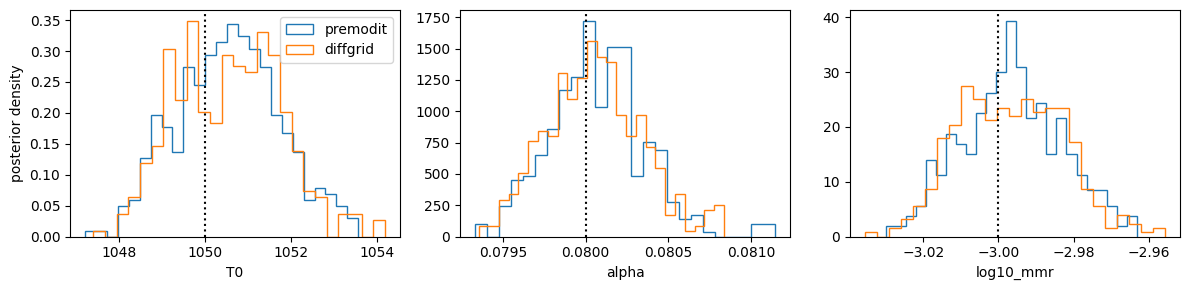

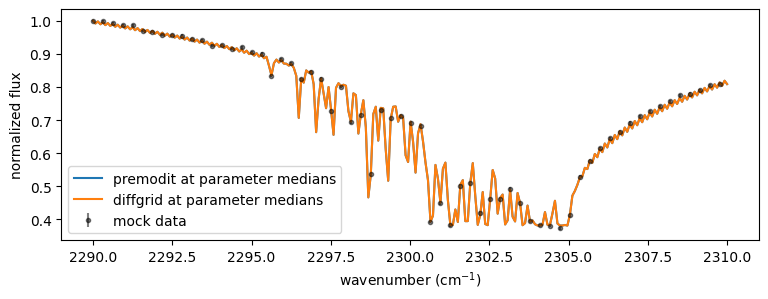

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for axis, parameter in zip(axes, parameter_names):
    for method, color in (("premodit", "C0"), ("diffgrid", "C1")):
        axis.hist(
            np.asarray(retrievals[method]["samples"][parameter]),
            bins=25,
            density=True,
            histtype="step",
            color=color,
            label=method,
        )
    axis.axvline(truth[parameter], color="black", linestyle=":")
    axis.set_xlabel(parameter)
axes[0].set_ylabel("posterior density")
axes[0].legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 3))
plt.errorbar(
    np.asarray(nu_grid)[::4],
    observed_flux,
    yerr=noise_sigma,
    fmt=".",
    color="black",
    alpha=0.5,
    label="mock data",
)
for method, color in (("premodit", "C0"), ("diffgrid", "C1")):
    samples = retrievals[method]["samples"]
    median_parameters = tuple(
        float(jnp.median(samples[parameter]))
        for parameter in parameter_names
    )
    median_flux = np.asarray(forward_models[method](*median_parameters))
    plt.plot(
        nu_grid,
        median_flux,
        color=color,
        label=f"{method} at parameter medians",
    )
plt.xlabel("wavenumber (cm$^{-1}$)")
plt.ylabel("normalized flux")
plt.legend()
plt.show()

## Interpretation and production use

- The one-time Diffgrid build should not be counted as per-sample opacity time. It is amortized over the many forward and gradient evaluations made by NUTS.
- NUTS wall-clock speed includes different trajectory lengths and shared compilation caches. Use the warm forward latency, `mean_num_steps`, and `ESS/s_including_compile` together, and reverse the run order or use separate processes for a dedicated benchmark.
- The table is valid only for `art.pressure`. Rebuild it if the pressure grid or number of layers changes.
- Every temperature allowed by the prior must remain inside the table range. A traced out-of-range temperature produces invalid likelihood values rather than pressure or temperature extrapolation.
- Repeat the error-in-noise check with the real database, spectral model, and noise level. Add inverse-temperature nodes until the interpolation error is negligible for the intended retrieval.
- The example retains both opacity calculators for comparison. A Diffgrid-only workflow does not need to keep the teacher after table construction.
- Small line lists may not benefit from Diffgrid. The measured speed-up is specific to the model, backend, hardware, node count, layer count, and spectral grid used here.